In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("Car details v3.csv")

In [3]:
df.head(5)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [4]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [5]:
df = df.dropna()

In [6]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
torque           0
seats            0
dtype: int64

In [7]:
df.head(2)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0


In [8]:
df.shape

(7906, 13)

In [9]:
x = df[['name', 'year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats']]
x = pd.get_dummies(x, columns= ['name', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque'])
y = df['selling_price']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)

In [11]:
rf = RandomForestRegressor()

In [12]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
X_test

,year,km_driven,seats,name_Ambassador CLASSIC 1500 DSL AC,name_Ambassador Classic 2000 DSZ AC PS,name_Ambassador Grand 1500 DSZ BSIII,name_Ambassador Grand 2000 DSZ PW CL,name_Ashok Leyland Stile LE,name_Audi A3 35 TDI Premium Plus,name_Audi A3 40 TFSI Premium,...,torque_96.1Nm@ 3000rpm,torque_96Nm@ 2500rpm,torque_96Nm@ 3000rpm,torque_96Nm@ 3500rpm,torque_98Nm@ 1600-3000rpm,torque_99.04Nm@ 4500rpm,torque_99.07Nm@ 4500rpm,torque_99.1Nm@ 4500rpm,torque_99.8Nm@ 2700rpm,torque_99Nm@ 4500rpm
3756,2014,68000,5.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5692,2015,110000,5.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3637,2012,185000,5.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7693,2012,90000,5.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3565,2018,15000,5.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1359,2013,100000,5.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
641,2010,168000,7.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1465,2010,50000,5.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4414,2017,9000,5.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [14]:
y_test

3756     501000
5692     440000
3637     140000
7693     476999
3565     620000
         ...   
1359     330000
641      229999
1465     144000
4414    2711000
8040     680000
Name: selling_price, Length: 1582, dtype: int64

In [15]:
y_pred = rf.predict(X_test)
y_pred

array([ 523038.31333333,  518043.80952381,  170660.        , ...,
        217399.81      , 2678516.6613222 ,  660169.99      ],
      shape=(1582,))

In [16]:
r2 = r2_score(y_test, y_pred)
r2

0.9635879601403915

In [17]:
mse = mean_squared_error(y_test , y_pred)
mse

25316673786.064465

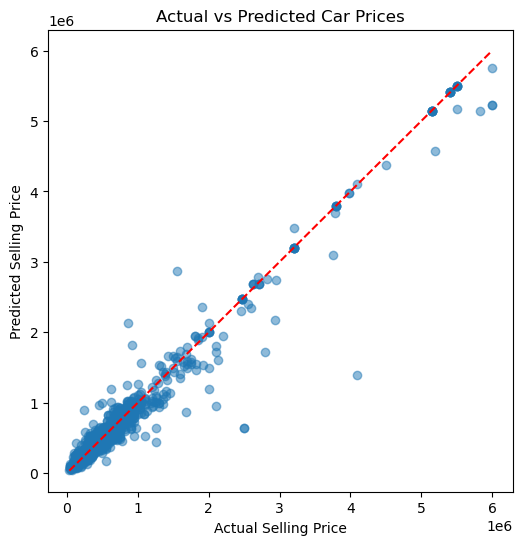

In [18]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

In [19]:
from sklearn.model_selection import GridSearchCV

In [20]:
param = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split': [2, 3, 5, 10],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': [None, 'sqrt', 'log2']
}

In [21]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [23]:
pickle.dump(rf, open("model.pkl", "wb"))